<a href="https://colab.research.google.com/github/kmr26-aman/house-price-prediction/blob/main/Aman.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **DATA ANALYTICS**
# Submitted by-
# Name : AMAN KUMAR
# Roll Number : 81
# PRN : 2314110521





In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import IsolationForest

 **QUESTION : 1**


In [7]:
df = pd.read_csv('/content/sample_data/insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [8]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [9]:
print("Missing Values:\n", df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

Missing Values:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
Duplicates: 1


In [10]:
df['smoker'] = df['smoker'].map({'yes':1, 'no':0})
df = pd.get_dummies(df, columns=['region'])
df.head()

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,female,27.900,0,1,16884.92400,False,False,False,True
1,18,male,33.770,1,0,1725.55230,False,False,True,False
2,28,male,33.000,3,0,4449.46200,False,False,True,False
3,33,male,22.705,0,0,21984.47061,False,True,False,False
4,32,male,28.880,0,0,3866.85520,False,True,False,False


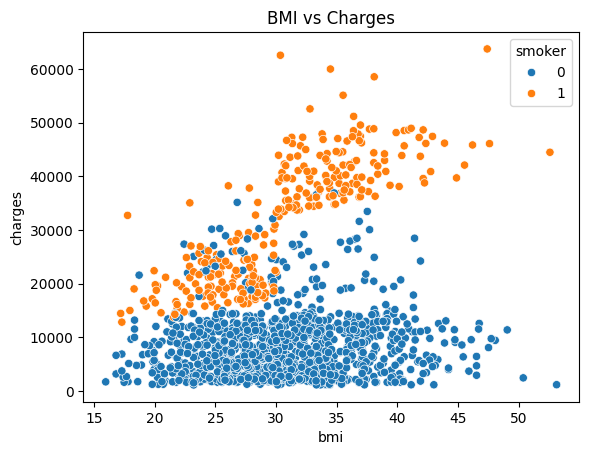

In [11]:
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df)
plt.title("BMI vs Charges")
plt.show()

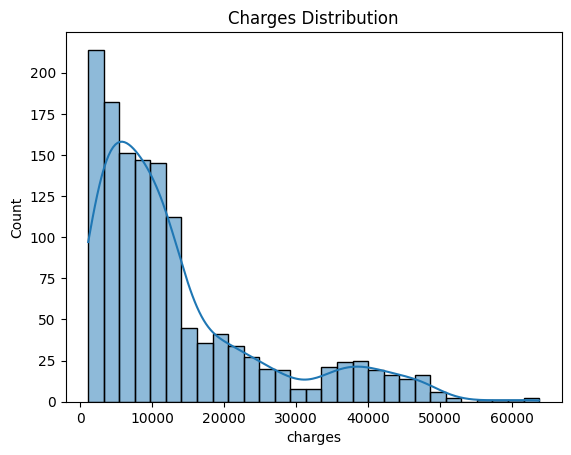

In [12]:
sns.histplot(df['charges'], kde=True)
plt.title("Charges Distribution")
plt.show()

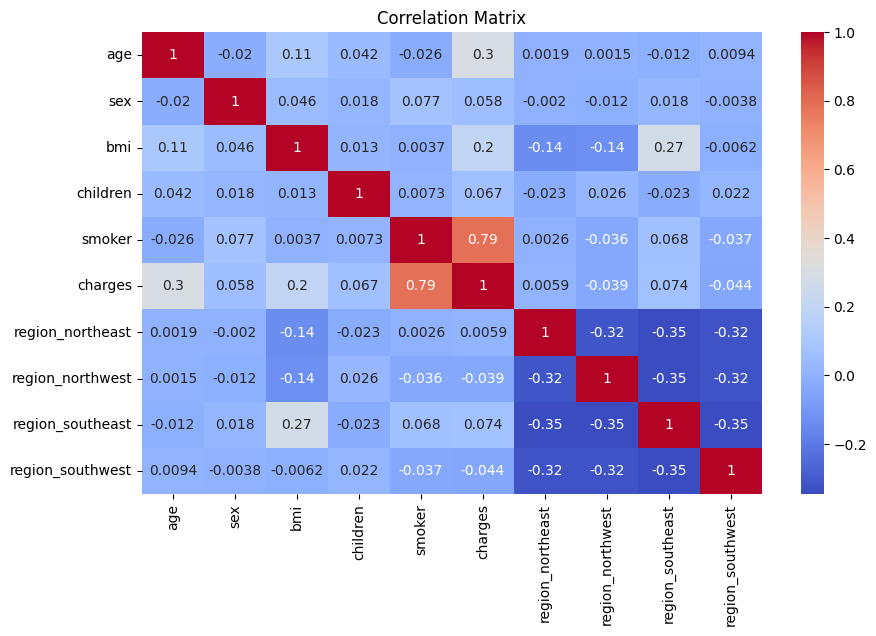

In [14]:
plt.figure(figsize=(10,6))
df['sex'] = df['sex'].map({'female':0, 'male':1}) # Convert 'sex' column to numerical
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

**QUESTION : 2**

In [15]:
hr = pd.read_csv('/content/sample_data/HR_comma_sep.csv')
hr.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [16]:
cols = ['satisfaction_level','last_evaluation','number_project','average_montly_hours','time_spend_company']

summary = pd.DataFrame({
    'Mean': hr[cols].mean(),
    'Median': hr[cols].median(),
    'Std Dev': hr[cols].std(),
    'Variance': hr[cols].var()
})

summary

,Mean,Median,Std Dev,Variance
satisfaction_level,0.612834,0.64,0.248631,0.061817
last_evaluation,0.716102,0.72,0.171169,0.029299
number_project,3.803054,4.00,1.232592,1.519284
average_montly_hours,201.050337,200.00,49.943099,2494.313175
time_spend_company,3.498233,3.00,1.460136,2.131998


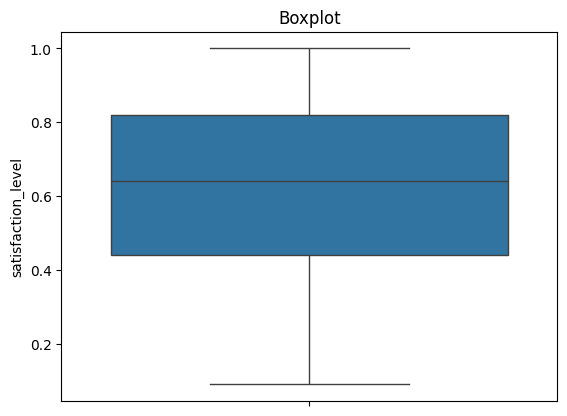

In [18]:
sns.boxplot(hr['satisfaction_level'])
plt.title("Boxplot")
plt.show()

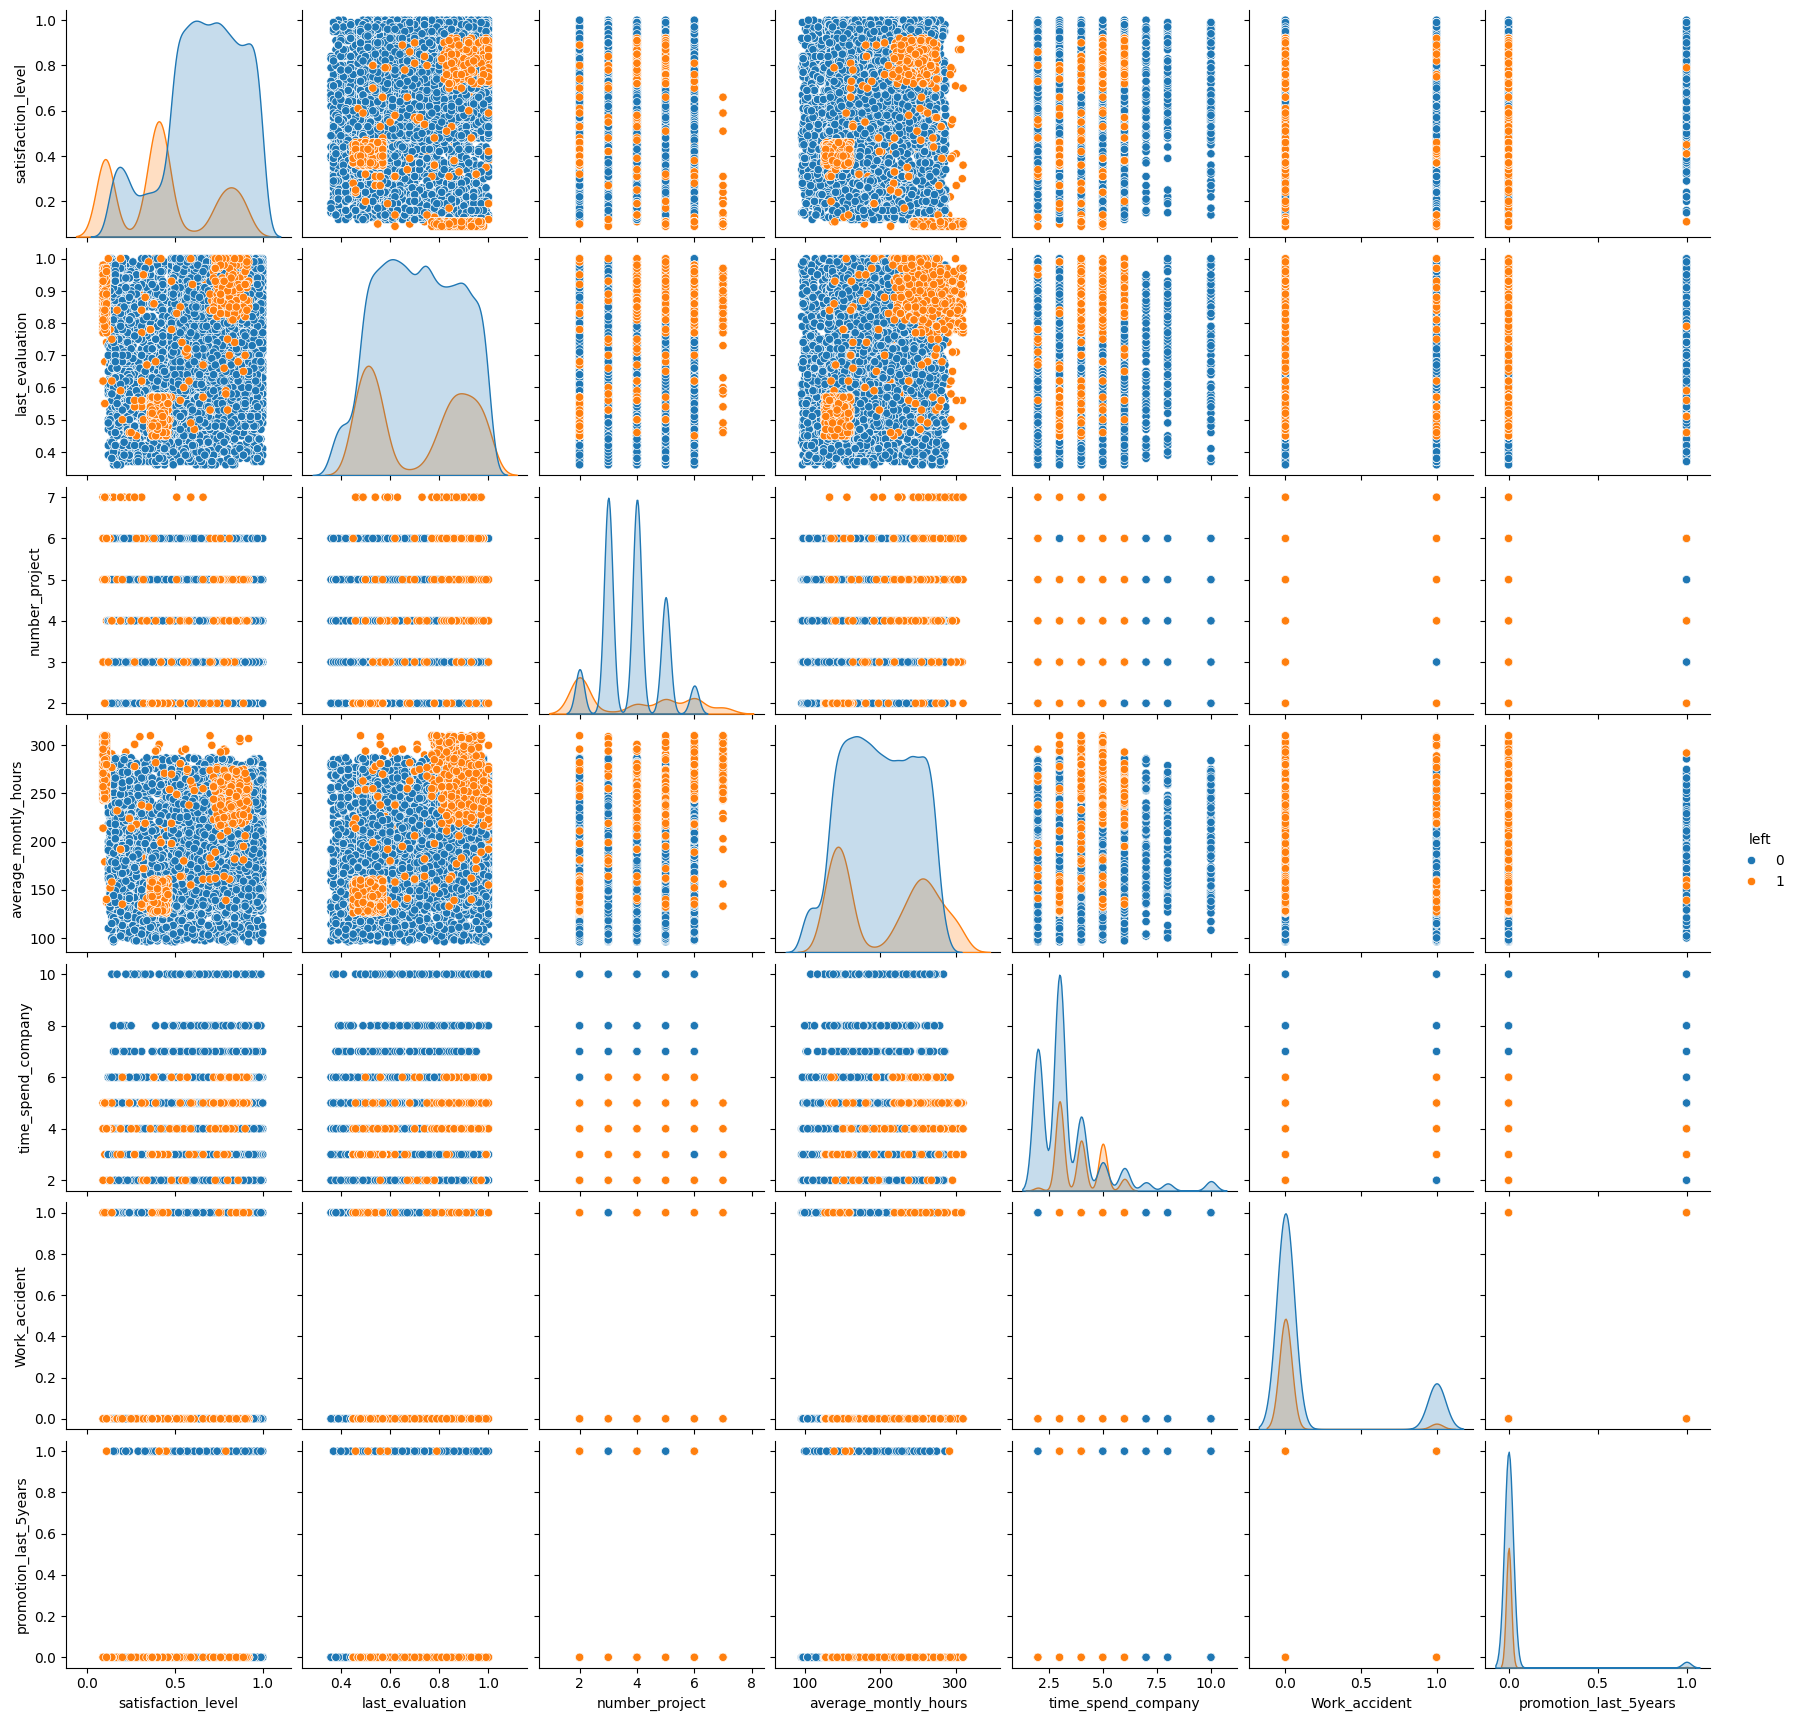

In [19]:
sns.pairplot(hr, hue='left')
plt.show()

In [20]:
print(hr['last_evaluation'].corr(hr['number_project']))

0.3493325885162622


**QUESTION : 3**

In [21]:
wine = pd.read_csv('/content/sample_data/wine.csv')
data = wine.iloc[:10, :6]
data

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg
0,1,14.23,1.71,2.43,15.6,127
1,1,13.20,1.78,2.14,11.2,100
2,1,13.16,2.36,2.67,18.6,101
3,1,14.37,1.95,2.50,16.8,113
4,1,13.24,2.59,2.87,21.0,118
5,1,14.20,1.76,2.45,15.2,112
6,1,14.39,1.87,2.45,14.6,96
7,1,14.06,2.15,2.61,17.6,121
8,1,14.83,1.64,2.17,14.0,97
9,1,13.86,1.35,2.27,16.0,98


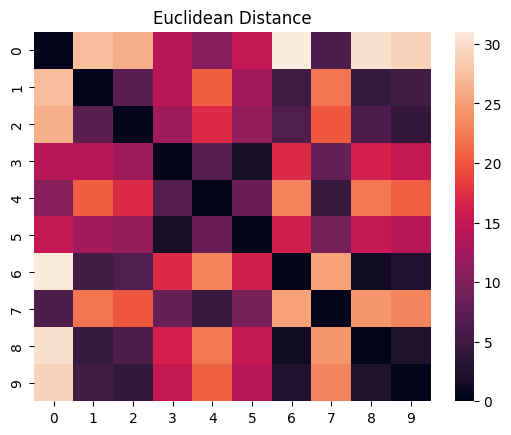

In [22]:
euclidean = cdist(data, data, metric='euclidean')
sns.heatmap(euclidean)
plt.title("Euclidean Distance")
plt.show()

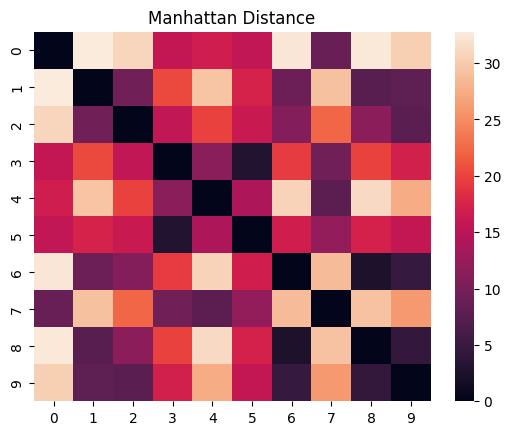

In [23]:
manhattan = cdist(data, data, metric='cityblock')
sns.heatmap(manhattan)
plt.title("Manhattan Distance")
plt.show()

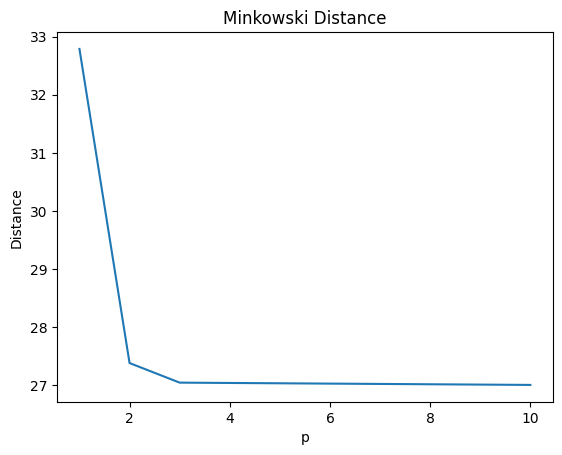

In [24]:
from scipy.spatial.distance import minkowski

p_values = [1,2,3,10]
distances = []

for p in p_values:
    d = minkowski(data.iloc[0], data.iloc[1], p)
    distances.append(d)

plt.plot(p_values, distances)
plt.title("Minkowski Distance")
plt.xlabel("p")
plt.ylabel("Distance")
plt.show()

In [25]:
print(hr.isnull().sum())
print("Duplicates:", hr.duplicated().sum())

hr.drop_duplicates(inplace=True)

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
sales                    0
salary                   0
dtype: int64
Duplicates: 3008


In [27]:
scaler = MinMaxScaler()
hr[['satisfaction_level']] = scaler.fit_transform(hr[['satisfaction_level']])

In [28]:
scaler = StandardScaler()
hr[['average_montly_hours']] = scaler.fit_transform(hr[['average_montly_hours']])

**QUESTION : 4**

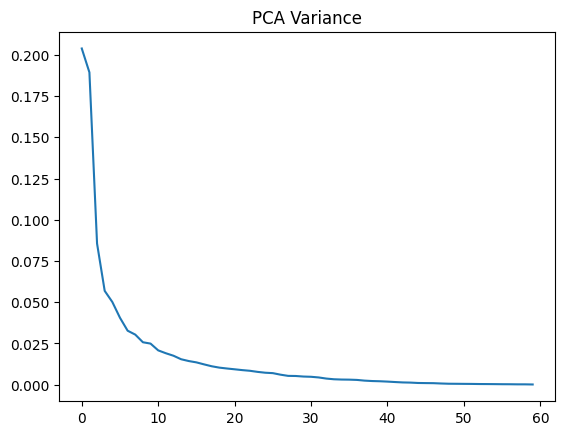

In [29]:
sonar = pd.read_csv('/content/sample_data/sonar.csv')

X = sonar.iloc[:, :-1]
y = sonar.iloc[:, -1]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

plt.plot(pca.explained_variance_ratio_)
plt.title("PCA Variance")
plt.show()

**QUESTION : 5**

In [30]:
sat = pd.read_csv('/content/sample_data/satellite.csv', delimiter=';')
sat.head()

,"V0,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,class"
0,"92,115,120,94,84,102,106,79,84,102,102,83,101,..."
1,"84,102,106,79,84,102,102,83,80,102,102,79,92,1..."
2,"84,102,102,83,80,102,102,79,84,94,102,79,84,10..."
3,"80,102,102,79,84,94,102,79,80,94,98,76,84,99,1..."
4,"84,94,102,79,80,94,98,76,80,102,102,79,84,99,1..."


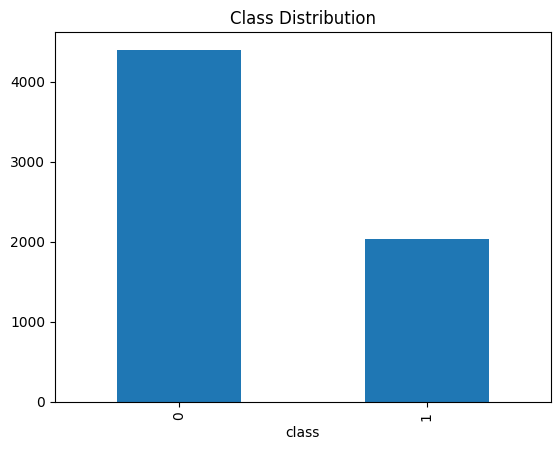

In [32]:
sat = pd.read_csv('/content/sample_data/satellite.csv') # Reload sat correctly, assuming comma-separated
sat['class'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.show()

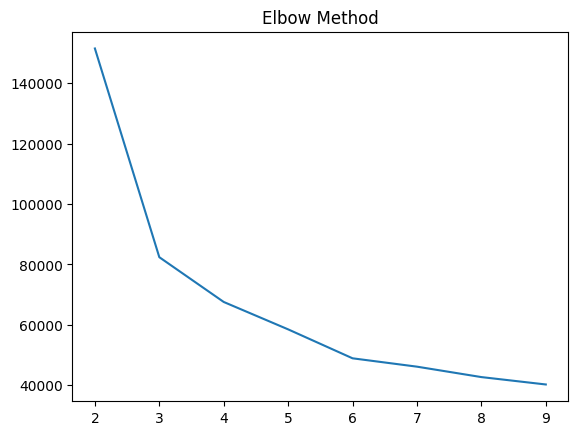

In [33]:
X = sat.iloc[:, :-1]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia = []
for k in range(2,10):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(2,10), inertia)
plt.title("Elbow Method")
plt.show()

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, sat['class'], test_size=0.2)

model = DecisionTreeClassifier(max_depth=5)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.94      0.91       877
           1       0.85      0.73      0.79       410

    accuracy                           0.87      1287
   macro avg       0.87      0.84      0.85      1287
weighted avg       0.87      0.87      0.87      1287



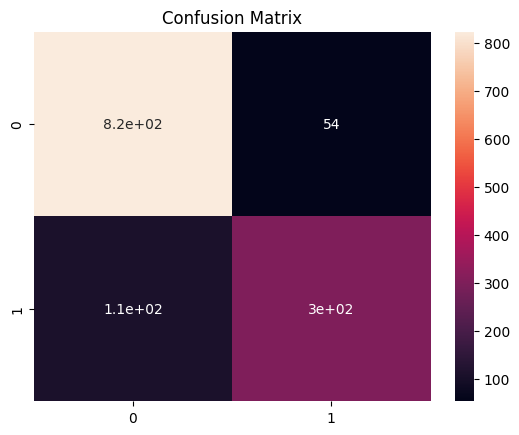

In [35]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True)
plt.title("Confusion Matrix")
plt.show()

In [36]:
iso = IsolationForest(contamination=0.05)
outliers = iso.fit_predict(X_scaled)

print("Outliers:", np.sum(outliers == -1))

Outliers: 322


**QUESTION : 6**

In [37]:
"""
Predict employee attrition and analyze insurance charges using machine learning.
"""

'\nPredict employee attrition and analyze insurance charges using machine learning.\n'

In [38]:
X = hr.drop('left', axis=1)
y = hr['left']

X = pd.get_dummies(X)

X_train, X_test, y_train, y_test = train_test_split(X, y)

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.9673115410273516


In [41]:
nutrient = pd.read_csv('/content/sample_data/nutrient.csv')

# Randomly assign food items to insurance data
insurance = df.copy() # Assuming 'df' from previous cells is the insurance data
insurance['Food_Item'] = np.random.choice(nutrient['name'], size=len(insurance))

# Merge datasets
data = pd.merge(insurance, nutrient, left_on='Food_Item', right_on='name')
data.head()

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,Food_Item,id,name,unit_name,nutrient_nbr,rank
0,19,0,27.900,0,1,16884.92400,False,False,False,True,Chrysoeriol,1380,Chrysoeriol,MG,771.0,22000.0
1,18,1,33.770,1,0,1725.55230,False,False,True,False,Phospholipids,1255,Phospholipids,G,603.0,999999.0
2,28,1,33.000,3,0,4449.46200,False,False,True,False,5-methyl tetrahydrofolate (5-MTHF),1188,5-methyl tetrahydrofolate (5-MTHF),UG,433.0,999999.0
3,33,1,22.705,0,0,21984.47061,False,True,False,False,Proximates,2045,Proximates,G,951.0,50.0
4,32,1,28.880,0,0,3866.85520,False,True,False,False,"ORAC, Hydrophyllic",1336,"ORAC, Hydrophyllic",UMOL_TE,706.0,NaN


In [44]:
print("Columns in 'data' DataFrame:", data.columns)

# Create Health Risk Score
data['risk_score'] = (
    data['bmi'] * 0.3 +
    data['age'] * 0.2
    # data['fat'] * 0.3 + # 'fat' column not found in data
    # data['Protein'] * 0.2 # 'Protein' column not found in data. Check data.columns above.
)

Columns in 'data' DataFrame: Index(['age', 'sex', 'bmi', 'children', 'smoker', 'charges',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest', 'Food_Item', 'id', 'name', 'unit_name',
       'nutrient_nbr', 'rank'],
      dtype='object')


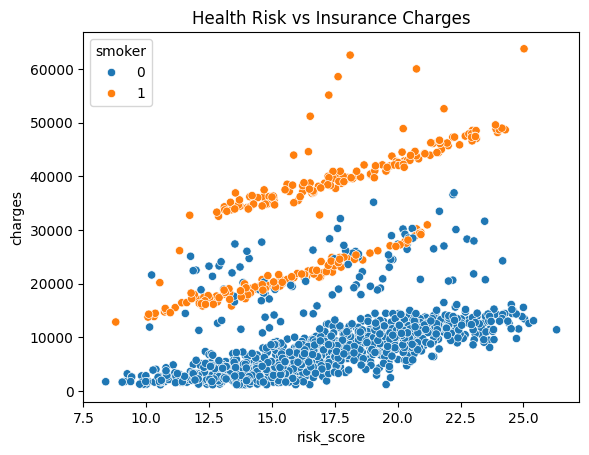

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x='risk_score', y='charges', hue='smoker', data=data)
plt.title("Health Risk vs Insurance Charges")
plt.show()

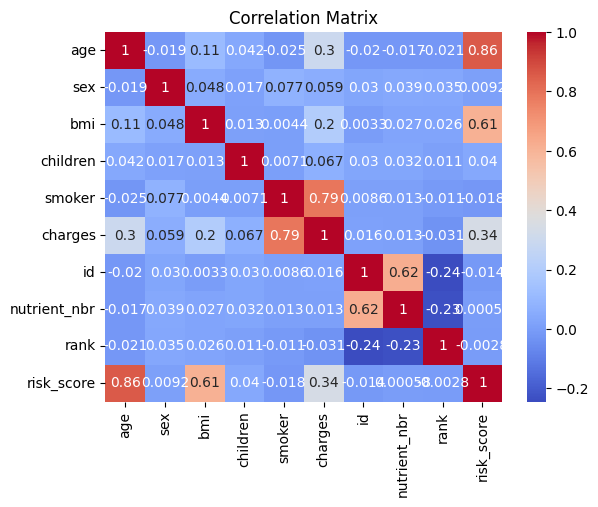

In [47]:
import numpy as np
sns.heatmap(data.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [49]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Prepare data
X = data[['age','bmi','risk_score']]
y = data['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y)

model = LinearRegression()
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.08512136469170206


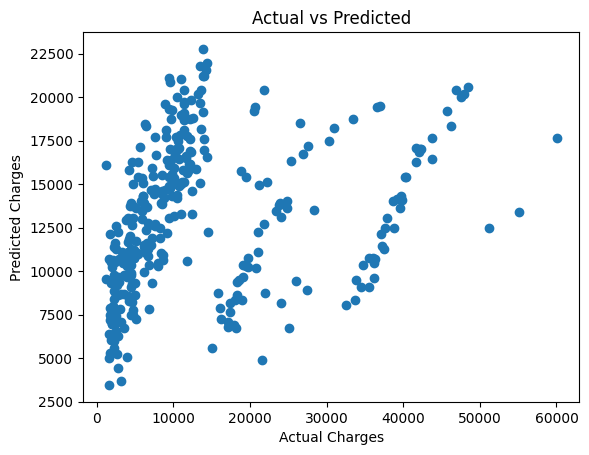

In [50]:
y_pred = model.predict(X_test)

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted")
plt.show()

***The End !***